# 1D Holstein nu16 plots

This notebook discovers available `Holstein31_alpha*_bd_{singleset,multiset}.npz` files under `1DHolstein_nu16` and generates:

1. Electron-phonon entanglement entropy, five alpha subfigures in one figure.
2. RMSD vs time, one figure per alpha with a zoom panel for `t/(2π) = [7.5, 8]`.
3. Maximum bond entropy vs time, one figure per alpha.


In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 8.2,
    "axes.grid": True,
    "grid.alpha": 0.26,
    "lines.solid_capstyle": "round",
})

TIME_SCALE = 2 * np.pi
ZOOM_XLIM = (7.5, 8.0)
MAIN_YLIM = (0.0, 11.0)
ZOOM_Y_TICK_STEP = 0.5
SAVE_FIGURES = True
ALPHA_ORDER = [0.25, 0.5, 1.0, 2.0, 4.0]
BOND_ORDER = [16, 32, 64]
METHOD_ORDER = ["multiset", "singleset"]

METHOD_STYLE = {
    "multiset": "-",
    "singleset": "--",
}
BOND_COLOR = {
    16: "#2f6fbb",
    32: "#d9822b",
    64: "#238b45",
}


def find_base_dir():
    candidates = [
        Path.cwd(),
        Path.cwd() / "multiset_202606" / "1DHolstein_nu16",
        Path("multiset_202606") / "1DHolstein_nu16",
    ]
    for path in candidates:
        if (path / "holstein31_common.py").exists():
            return path.resolve()
    raise FileNotFoundError("Cannot find multiset_202606/1DHolstein_nu16.")


BASE_DIR = find_base_dir()
FIG_DIR = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

print(f"BASE_DIR = {BASE_DIR}")
print(f"FIG_DIR  = {FIG_DIR}")


BASE_DIR = /curie-home/zengjj/Renormalizer/multiset_202606/1DHolstein_nu16
FIG_DIR  = /curie-home/zengjj/Renormalizer/multiset_202606/1DHolstein_nu16/figures


In [ ]:
RESULT_RE = re.compile(
    r"Holstein31_alpha(?P<alpha>[0-9.]+)_(?P<bd>\d+)bd_(?P<method>single|multi)set\.npz$"
)


def alpha_sort_value(alpha):
    try:
        return ALPHA_ORDER.index(alpha)
    except ValueError:
        return len(ALPHA_ORDER) + alpha


def record_sort_key(record):
    method_rank = METHOD_ORDER.index(record["method"]) if record["method"] in METHOD_ORDER else 99
    bond_rank = BOND_ORDER.index(record["bd"]) if record["bd"] in BOND_ORDER else 99
    return alpha_sort_value(record["alpha"]), method_rank, bond_rank


def discover_results(base_dir=BASE_DIR):
    records = []
    for path in sorted(base_dir.rglob("Holstein31_alpha*_*bd_*.npz")):
        match = RESULT_RE.match(path.name)
        if not match:
            continue
        alpha = float(match.group("alpha"))
        bd = int(match.group("bd"))
        method = f"{match.group('method')}set"
        records.append({
            "alpha": alpha,
            "bd": bd,
            "method": method,
            "path": path,
        })
    return sorted(records, key=record_sort_key)


def load_npz(record):
    data = np.load(record["path"], allow_pickle=True)
    return data


def array_from_npz(data, key):
    if key not in data.files:
        raise KeyError(f"missing key {key!r}; available keys: {data.files}")
    return np.asarray(np.real_if_close(data[key]), dtype=float)


def time_axis(data):
    return array_from_npz(data, "time_series") / TIME_SCALE


def compute_rmsd_from_occupations(occupations):
    occupations = np.asarray(occupations, dtype=float)
    if occupations.ndim != 2:
        raise ValueError(f"e_occupations should be 2D, got shape {occupations.shape}")

    n_site = occupations.shape[1]
    center = (n_site - 1) / 2
    x = np.arange(n_site, dtype=float)

    norm = occupations.sum(axis=1, keepdims=True)
    rho = np.divide(
        occupations,
        norm,
        out=np.zeros_like(occupations, dtype=float),
        where=np.abs(norm) > 1e-14,
    )
    return np.sqrt(np.sum((x - center) ** 2 * rho, axis=1))


def line_label(record):
    return rf"$\chi={record['bd']}$, {record['method']}"


def line_kwargs(record):
    return {
        "lw": 2.0,
        "ls": METHOD_STYLE.get(record["method"], "-"),
        "color": BOND_COLOR.get(record["bd"], "0.35"),
    }


def alpha_tag(alpha):
    return f"{alpha:g}".replace(".", "p")


records = discover_results()
summary = pd.DataFrame({
    "alpha": [record["alpha"] for record in records],
    "method": [record["method"] for record in records],
    "bond_dim": [record["bd"] for record in records],
    "file": [record["path"].relative_to(BASE_DIR).as_posix() for record in records],
})
print(f"Discovered {len(records)} npz result files.")
try:
    display(summary)
except NameError:
    print(summary.to_string(index=False))


Discovered 30 npz result files.


,alpha,method,bond_dim,file
0,0.25,multiset,16,Holstein31_alpha0.25/multiset/Holstein31_alpha...
1,0.25,multiset,32,Holstein31_alpha0.25/multiset/Holstein31_alpha...
2,0.25,multiset,64,Holstein31_alpha0.25/multiset/Holstein31_alpha...
3,0.25,singleset,16,Holstein31_alpha0.25/singleset/Holstein31_alph...
4,0.25,singleset,32,Holstein31_alpha0.25/singleset/Holstein31_alph...
5,0.25,singleset,64,Holstein31_alpha0.25/singleset/Holstein31_alph...
6,0.50,multiset,16,Holstein31_alpha0.5/multiset/Holstein31_alpha0...
7,0.50,multiset,32,Holstein31_alpha0.5/multiset/Holstein31_alpha0...
8,0.50,multiset,64,Holstein31_alpha0.5/multiset/Holstein31_alpha0...
9,0.50,singleset,16,Holstein31_alpha0.5/singleset/Holstein31_alpha...


## Fig. 1: Electron-Phonon Entanglement Entropy

Five alpha values are drawn as five subfigures in one large figure. Solid lines are multiset, dashed lines are singleset, and colors identify bond dimension.

Fig. 1 plotted 30 curves.


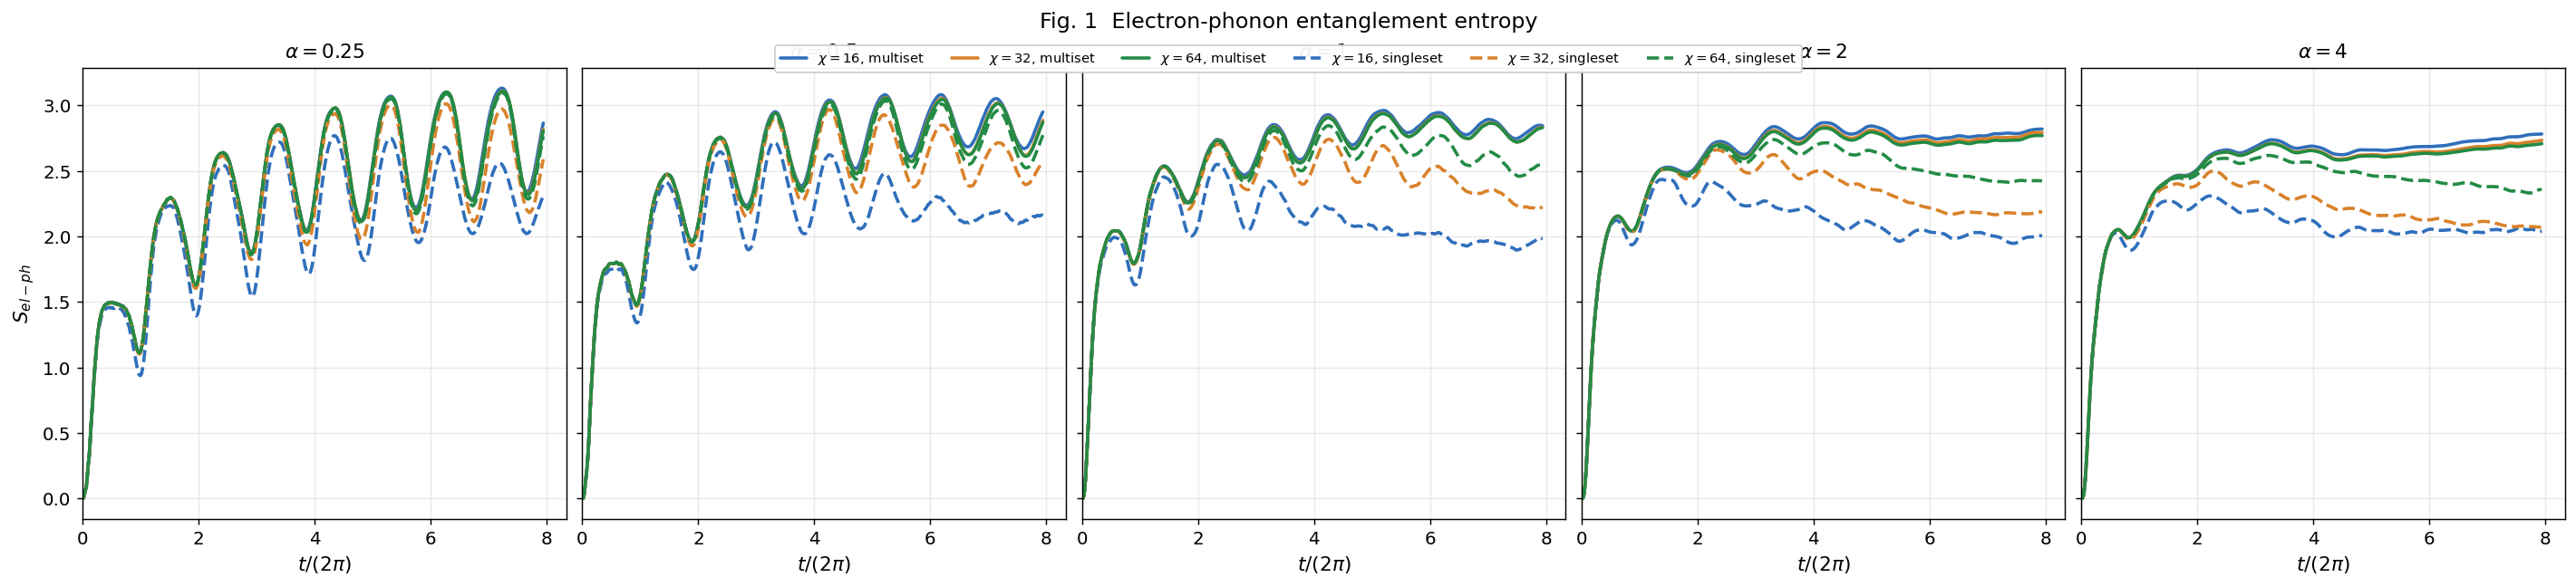

In [ ]:
def plot_fig1_entropy(records):
    fig, axes = plt.subplots(
        1,
        len(ALPHA_ORDER),
        figsize=(4.35 * len(ALPHA_ORDER), 5.1),
        sharey=True,
        constrained_layout=False,
    )
    if len(ALPHA_ORDER) == 1:
        axes = [axes]

    plotted = 0
    handles = {}

    for ax, alpha in zip(axes, ALPHA_ORDER):
        alpha_records = [record for record in records if np.isclose(record["alpha"], alpha)]
        for record in alpha_records:
            data = load_npz(record)
            if "S_el" not in data.files:
                print(f"[skip] no S_el: {record['path'].relative_to(BASE_DIR)}")
                continue
            t = time_axis(data)
            entropy = array_from_npz(data, "S_el")
            n = min(len(t), len(entropy))
            line, = ax.plot(t[:n], entropy[:n], label=line_label(record), **line_kwargs(record))
            handles.setdefault(line_label(record), line)
            plotted += 1

        ax.set_title(rf"$\alpha={alpha:g}$")
        ax.set_xlabel(r"$t/(2\pi)$")
        ax.set_xlim(left=0)

    axes[0].set_ylabel(r"$S_{el-ph}$")
    fig.suptitle("Fig. 1  Electron-phonon entanglement entropy", y=0.96)
    fig.subplots_adjust(left=0.055, right=0.995, bottom=0.22, top=0.84, wspace=0.10)
    fig.legend(
        handles.values(),
        handles.keys(),
        loc="lower center",
        bbox_to_anchor=(0.5, 0.035),
        ncol=6,
        frameon=True,
        framealpha=0.94,
    )

    if SAVE_FIGURES and plotted:
        fig.savefig(FIG_DIR / "fig1_el_ph_entropy_by_alpha.png", bbox_inches="tight")
        fig.savefig(FIG_DIR / "fig1_el_ph_entropy_by_alpha.pdf", bbox_inches="tight")

    print(f"Fig. 1 plotted {plotted} curves.")
    return fig, axes


fig1, axes1 = plot_fig1_entropy(records)
plt.show()


## Fig. 2: RMSD

One figure is produced for each alpha. The left panel shows the full time evolution; the right panel zooms into `t/(2π) = [7.5, 8]`.

Fig. 2 alpha=0.25: plotted 6 curves.
Fig. 2 alpha=0.5: plotted 6 curves.
Fig. 2 alpha=1: plotted 6 curves.
Fig. 2 alpha=2: plotted 6 curves.
Fig. 2 alpha=4: plotted 6 curves.
Fig. 2 plotted 30 curves in total.
Fig. 2 zoom y-span shared by all alpha panels: 2.5


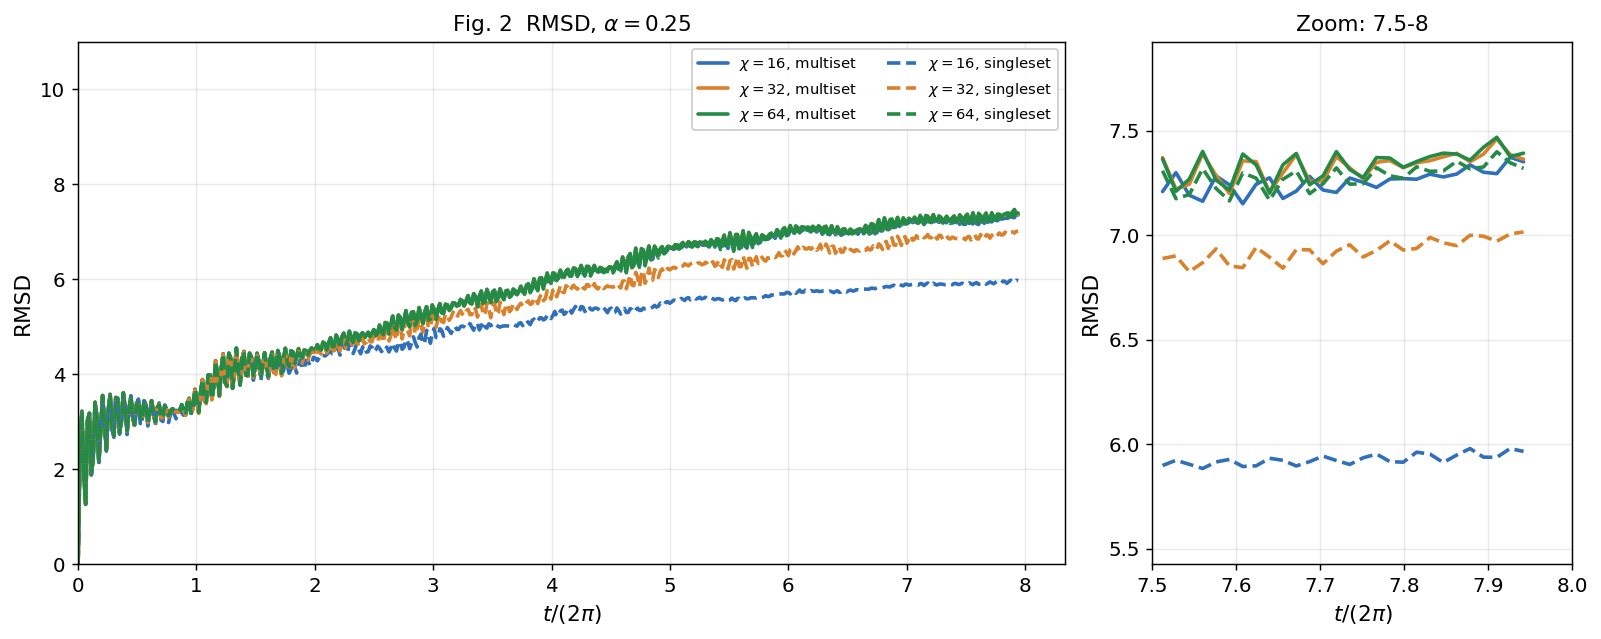

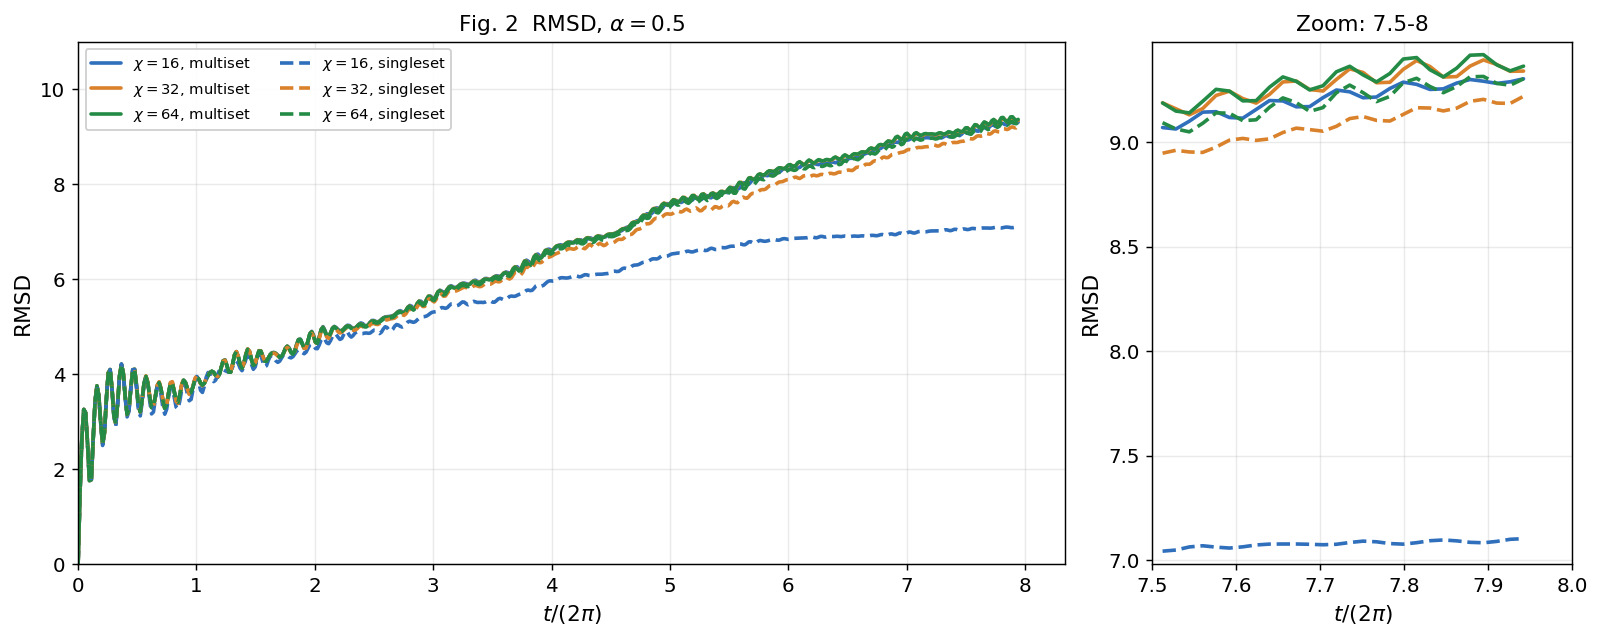

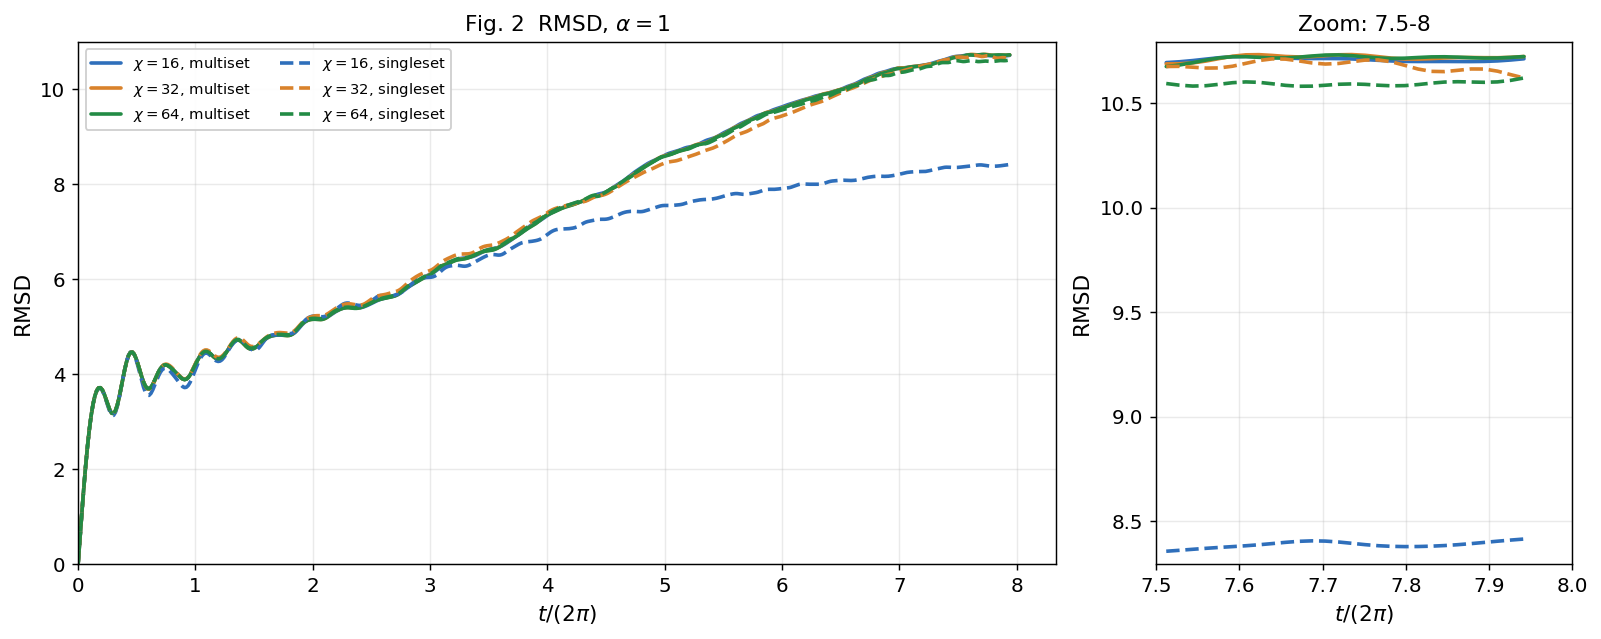

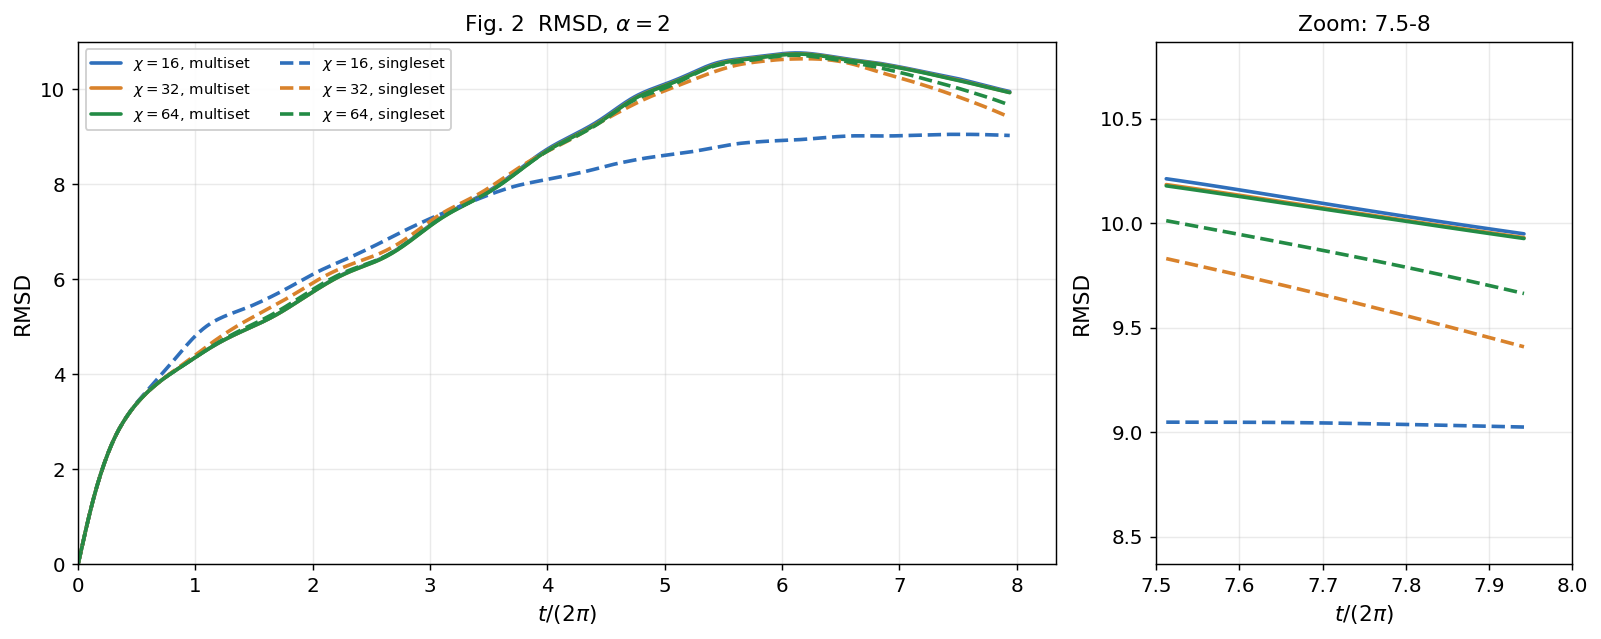

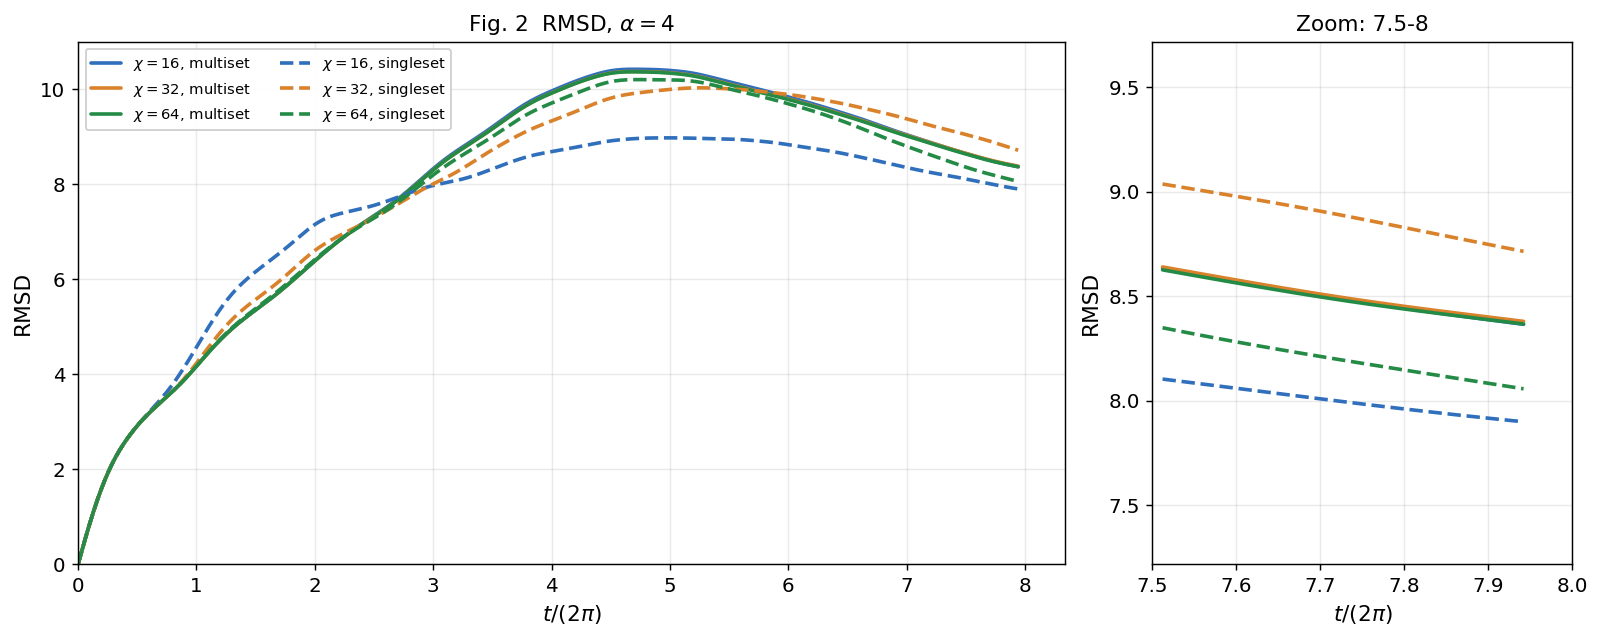

In [ ]:
def plot_fig2_rmsd(records, zoom_xlim=ZOOM_XLIM):
    figs_axes = []
    total_plotted = 0
    zoom_values_by_alpha = {}

    for alpha in ALPHA_ORDER:
        zoom_values = []
        for record in [record for record in records if np.isclose(record["alpha"], alpha)]:
            data = load_npz(record)
            t = time_axis(data)
            occupations = array_from_npz(data, "e_occupations")
            rmsd = compute_rmsd_from_occupations(occupations)
            n = min(len(t), len(rmsd))
            zoom_mask = (t[:n] >= zoom_xlim[0]) & (t[:n] <= zoom_xlim[1])
            zoom_values.extend(rmsd[:n][zoom_mask].tolist())
        if zoom_values:
            zoom_values_by_alpha[alpha] = np.asarray(zoom_values, dtype=float)

    max_zoom_span = max(
        (values.max() - values.min() for values in zoom_values_by_alpha.values()),
        default=ZOOM_Y_TICK_STEP,
    )
    zoom_y_span = np.ceil(max_zoom_span / ZOOM_Y_TICK_STEP) * ZOOM_Y_TICK_STEP

    for alpha in ALPHA_ORDER:
        alpha_records = [record for record in records if np.isclose(record["alpha"], alpha)]
        if not alpha_records:
            print(f"[skip] no records for alpha={alpha:g}")
            continue

        fig, (ax, ax_zoom) = plt.subplots(
            1,
            2,
            figsize=(12.2, 4.8),
            gridspec_kw={"width_ratios": [2.35, 1.0]},
            constrained_layout=True,
        )
        plotted = 0

        for record in alpha_records:
            data = load_npz(record)
            t = time_axis(data)
            occupations = array_from_npz(data, "e_occupations")
            rmsd = compute_rmsd_from_occupations(occupations)
            n = min(len(t), len(rmsd))
            t = t[:n]
            rmsd = rmsd[:n]

            kwargs = line_kwargs(record)
            label = line_label(record)
            ax.plot(t, rmsd, label=label, **kwargs)

            zoom_mask = (t >= zoom_xlim[0]) & (t <= zoom_xlim[1])
            ax_zoom.plot(t[zoom_mask], rmsd[zoom_mask], **kwargs)
            plotted += 1

        for axis in (ax, ax_zoom):
            axis.set_xlabel(r"$t/(2\pi)$")
            axis.set_ylabel("RMSD")

        ax.set_title(rf"Fig. 2  RMSD, $\alpha={alpha:g}$")
        ax.set_xlim(left=0)
        ax.set_ylim(*MAIN_YLIM)
        ax.legend(ncol=2, frameon=True, framealpha=0.94)

        ax_zoom.set_title(rf"Zoom: {zoom_xlim[0]:g}-{zoom_xlim[1]:g}")
        ax_zoom.set_xlim(*zoom_xlim)
        zoom_values = zoom_values_by_alpha.get(alpha)
        if zoom_values is not None:
            center = 0.5 * (zoom_values.min() + zoom_values.max())
            y_min = center - 0.5 * zoom_y_span
            y_max = center + 0.5 * zoom_y_span
            ax_zoom.set_ylim(y_min, y_max)
            tick_start = np.ceil(y_min / ZOOM_Y_TICK_STEP) * ZOOM_Y_TICK_STEP
            tick_stop = np.floor(y_max / ZOOM_Y_TICK_STEP) * ZOOM_Y_TICK_STEP
            ax_zoom.set_yticks(np.arange(tick_start, tick_stop + 0.5 * ZOOM_Y_TICK_STEP, ZOOM_Y_TICK_STEP))

        if SAVE_FIGURES and plotted:
            tag = alpha_tag(alpha)
            fig.savefig(FIG_DIR / f"fig2_rmsd_alpha_{tag}.png", bbox_inches="tight")
            fig.savefig(FIG_DIR / f"fig2_rmsd_alpha_{tag}.pdf", bbox_inches="tight")

        print(f"Fig. 2 alpha={alpha:g}: plotted {plotted} curves.")
        total_plotted += plotted
        figs_axes.append((fig, ax, ax_zoom))

    print(f"Fig. 2 plotted {total_plotted} curves in total.")
    print(f"Fig. 2 zoom y-span shared by all alpha panels: {zoom_y_span:g}")
    return figs_axes


fig2_axes = plot_fig2_rmsd(records)
plt.show()


## Fig. 3: Maximum Bond Entropy

One figure is produced for each alpha, showing maximum bond entropy versus time for available singleset and multiset results.

Fig. 3 alpha=0.25: plotted 6 curves.
Fig. 3 alpha=0.5: plotted 6 curves.
Fig. 3 alpha=1: plotted 6 curves.
Fig. 3 alpha=2: plotted 6 curves.
Fig. 3 alpha=4: plotted 6 curves.
Fig. 3 plotted 30 curves in total.


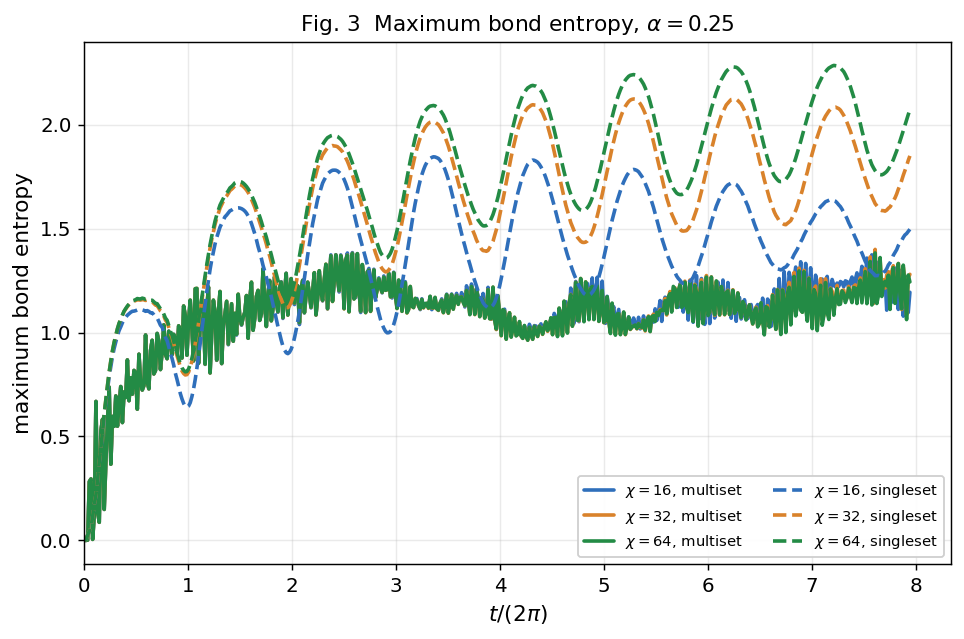

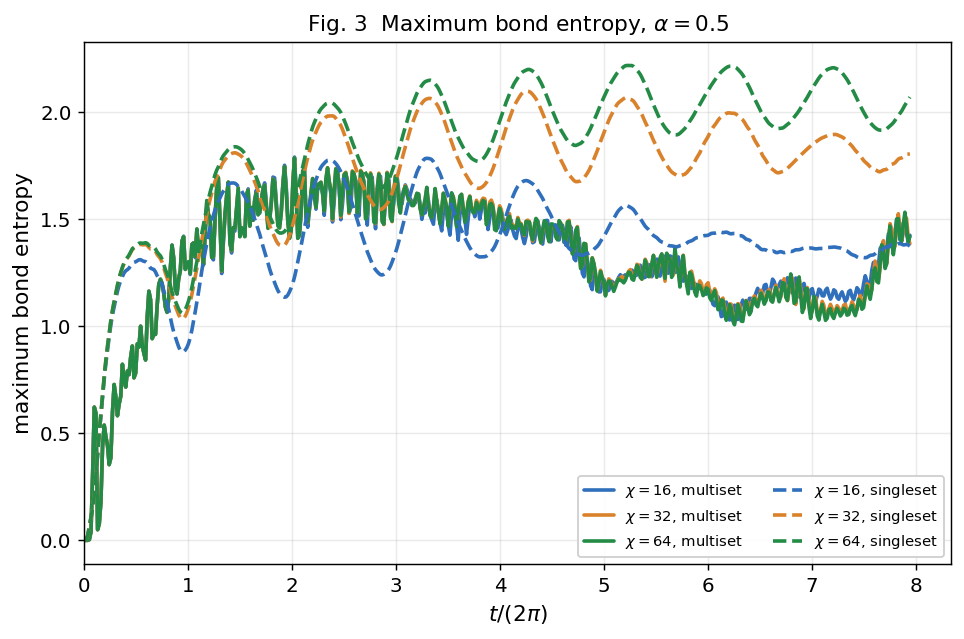

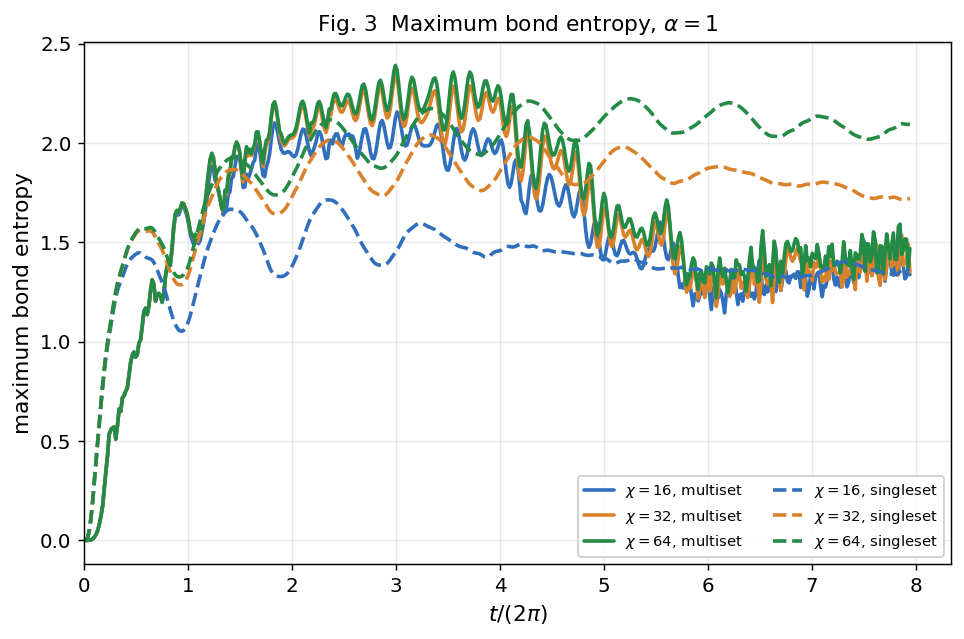

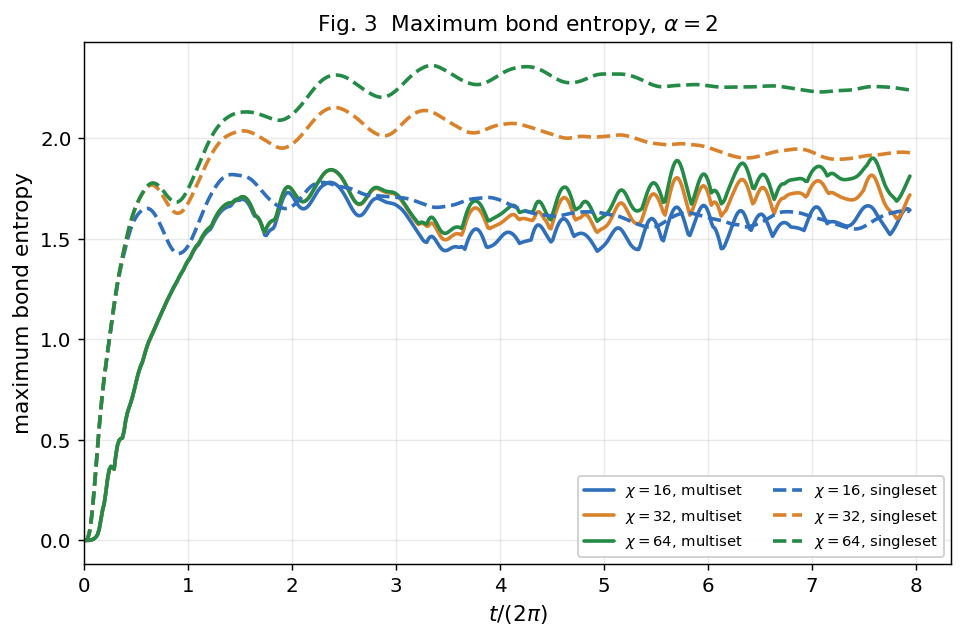

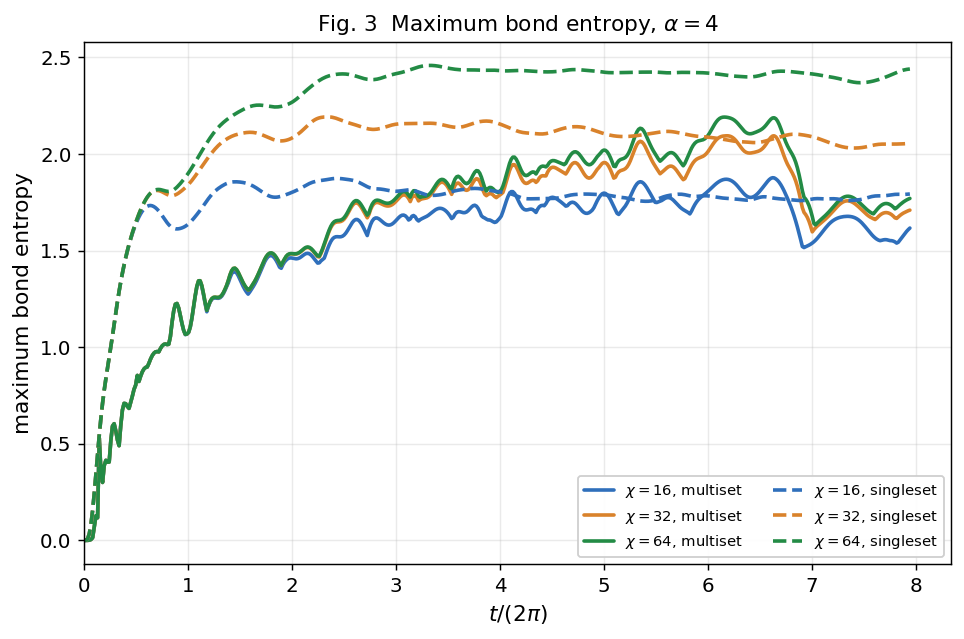

In [ ]:
def plot_fig3_max_bond_entropy(records):
    figs_axes = []
    total_plotted = 0

    for alpha in ALPHA_ORDER:
        alpha_records = [record for record in records if np.isclose(record["alpha"], alpha)]
        if not alpha_records:
            print(f"[skip] no records for alpha={alpha:g}")
            continue

        fig, ax = plt.subplots(figsize=(7.3, 4.8), constrained_layout=True)
        plotted = 0

        for record in alpha_records:
            data = load_npz(record)
            if "S_maxbond" not in data.files:
                print(f"[skip] no S_maxbond: {record['path'].relative_to(BASE_DIR)}")
                continue
            t = time_axis(data)
            s_maxbond = array_from_npz(data, "S_maxbond")
            n = min(len(t), len(s_maxbond))
            ax.plot(t[:n], s_maxbond[:n], label=line_label(record), **line_kwargs(record))
            plotted += 1

        ax.set_title(rf"Fig. 3  Maximum bond entropy, $\alpha={alpha:g}$")
        ax.set_xlabel(r"$t/(2\pi)$")
        ax.set_ylabel("maximum bond entropy")
        ax.set_xlim(left=0)
        ax.legend(ncol=2, frameon=True, framealpha=0.94)

        if SAVE_FIGURES and plotted:
            tag = alpha_tag(alpha)
            fig.savefig(FIG_DIR / f"fig3_max_bond_entropy_alpha_{tag}.png", bbox_inches="tight")
            fig.savefig(FIG_DIR / f"fig3_max_bond_entropy_alpha_{tag}.pdf", bbox_inches="tight")

        print(f"Fig. 3 alpha={alpha:g}: plotted {plotted} curves.")
        total_plotted += plotted
        figs_axes.append((fig, ax))

    print(f"Fig. 3 plotted {total_plotted} curves in total.")
    return figs_axes


fig3_axes = plot_fig3_max_bond_entropy(records)
plt.show()
